In [1]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
from SRtools import sr_mcmc as srmc
import argparse
from SRtools import config_lib as cl
from SRtools import deathTimesDataSet as dtds
import ast
from SRtools import readResults as rr
import corner
import matplotlib.pyplot as plt
import matplotlib
from SRtools import SRmodellib as sr
from SRtools import SRmodellib_lifelines as srl
from SRtools import samples_utils as su
from SRtools import SR_hetro as srh
from SRtools import joint_posterior as jp
from SRtools import presets

In [2]:
parallel =True


In [5]:
paths = ['mice_F','mice_M','yeast','ecoli','cats_vp_M', 'cats_vp_F',
        'drosophila_853','drosophila_707','drosophila_441','drosophila_217',
        'Sweden_M_1910_hetro','Sweden_F_1910_hetro','Denmark_M_1900_hetro','Denmark_M_1890_hetro',
        'Staffy_vetCompass','Labradors_vetCompass','Jack_Russell_vetCompass','German_Shepherd_vetCompass',
        'Denmark_F_1890_hetro',
        'celegans','Denmark_F_1900_hetro','Guiniea_pig_VC']

# Getting basline params and MLs

In [6]:
MLs = {}
MLs_normalized ={}
sims ={}
sims_normalized ={}

thetas_overall ={}
thetas_normalized ={}
thetas_mode ={}
configs ={}


for path in paths:
    theta =  np.array(presets.getTheta(path, time_unit='days'))
    thetas_overall[path] = presets.getTheta(path, time_unit='days')
    thetas_mode[path] = presets.getTheta(path, time_unit='days', type = 'mode')
    configs[path] = presets.get_config_params(path, time_unit='days',
                                            config_params =['nsteps', 'time_step_multiplier', 'npeople', 't_end','hetro'])
    sims[path] = srh.getSrHetro(thetas_overall[path],**configs[path],parallel=parallel)
    theta_normalized = np.array(presets.getParams(path, time_unit='days'))
    theta_normalized = 20*theta_normalized
    theta_normalized[2] *=20
    thetas_normalized[path] = theta_normalized
    sims_normalized[path] = srh.getSrHetro(thetas_normalized[path],**configs[path],parallel=parallel)
    MLs[path] = sims[path].getMedianLifetime()
    MLs_normalized[path] = sims_normalized[path].getMedianLifetime()


Using alias 'Staffy_vetCompass' -> 'Staffy_vetCompass'
Using alias 'Staffy_vetCompass' -> 'Staffy_vetCompass'
Using alias 'Staffy_vetCompass' -> 'Staffy_vetCompass'
Using alias 'Staffy_vetCompass' -> 'Staffy_vetCompass'
Using alias 'Staffy_vetCompass' -> 'Staffy_vetCompass'
Using alias 'celegans' -> 'celegans'
Using alias 'celegans' -> 'celegans'
Using alias 'celegans' -> 'celegans'
Using alias 'celegans' -> 'celegans'
Using alias 'celegans' -> 'celegans'


In [7]:
for path in paths:
    print(path,thetas_overall[path][3])

mice_F 29.7
mice_M 42.637
yeast 6101.382
ecoli 4.408
cats_vp_M 18.533
cats_vp_F 5.108
drosophila_853 3.678
drosophila_707 197.03
drosophila_441 406.44
drosophila_217 3158.555
Sweden_M_1910_hetro 13.662
Sweden_F_1910_hetro 6.326
Denmark_M_1900_hetro 30.275
Denmark_M_1890_hetro 6.154
Staffy_vetCompass 29.48
Labradors_vetCompass 14.203
Jack_Russell_vetCompass 0.443
German_Shepherd_vetCompass 195.835
Denmark_F_1890_hetro 13.203
celegans 44.248
Denmark_F_1900_hetro 15.961
Guiniea_pig_VC 458.389


In [8]:
for path in paths:
    # print(path+': ', (MLs[path]-MLs_normalized[path])/MLs[path])
    print(path+': ', MLs[path].round(2), MLs_normalized[path].round(2))


mice_F:  884.3 inf
mice_M:  748.25 inf
yeast:  3.14 inf
ecoli:  2.77 inf
cats_vp_M:  4849.99 inf
cats_vp_F:  5430.46 inf
drosophila_853:  45.73 inf
drosophila_707:  21.66 inf
drosophila_441:  49.89 inf
drosophila_217:  31.25 inf
Sweden_M_1910_hetro:  28142.75 inf
Sweden_F_1910_hetro:  30006.08 inf
Denmark_M_1900_hetro:  27114.7 inf
Denmark_M_1890_hetro:  27074.54 inf
Staffy_vetCompass:  4479.01 inf
Labradors_vetCompass:  4512.3 8590.02
Jack_Russell_vetCompass:  5006.47 29.79
German_Shepherd_vetCompass:  4028.65 inf
Denmark_F_1890_hetro:  27990.15 inf
celegans:  18.38 inf
Denmark_F_1900_hetro:  28656.77 inf
Guiniea_pig_VC:  1485.12 inf


# Calculate life span with geometric means and single param substitution
A complementary approach to identify which biological parameters are most important to explain the observed variation in lifespan, we performed a single-parameter substitution analysis. We simulated lifespans by varying one parameter at its dataset(species, breed, sex)-specific value while holding all others at their global (all datasets) geometric means.

In [9]:
indices ={'eta':0, 'beta':1, 'epsilon':2, 'xc':3}

sims_eta = {}
sims_beta = {}
sims_epsilon = {}
sims_xc = {}
MLs_eta = {}
MLs_beta = {}
MLs_epsilon = {}
MLs_xc = {}

mean_log_theta = np.mean(np.log(np.array(list(thetas_mode.values()))), axis=0)
mean_theta = np.exp(mean_log_theta)

# Compute maximal t_end across all configs
max_t_end = max(configs[path]['t_end'] for path in paths)
max_t_end *=2

for path in paths:
    orig_t_end = configs[path]['t_end']
    # Compute multiplier = floor(max_t_end / orig_t_end)
    multiplier = int(np.floor(max_t_end / orig_t_end))
    multiplier = min(multiplier, 25)
    # Set t_end to max_t_end and time_step_multiplier appropriately
    config_eta = configs[path].copy()
    config_eta['t_end'] = max_t_end
    config_eta['time_step_multiplier'] = config_eta['time_step_multiplier'] * multiplier
    theta_eta = mean_theta.copy()
    theta_eta[indices['eta']] = thetas_mode[path][indices['eta']]
    sims_eta[path] = srh.getSrHetro(theta_eta, **config_eta, parallel=parallel)

    config_beta = configs[path].copy()
    config_beta['t_end'] = max_t_end
    config_beta['time_step_multiplier'] = config_beta['time_step_multiplier'] * multiplier
    theta_beta = mean_theta.copy()
    theta_beta[indices['beta']] = thetas_mode[path][indices['beta']]
    sims_beta[path] = srh.getSrHetro(theta_beta, **config_beta, parallel=parallel)

    config_epsilon = configs[path].copy()
    config_epsilon['t_end'] = max_t_end
    config_epsilon['time_step_multiplier'] = config_epsilon['time_step_multiplier'] * multiplier
    theta_epsilon = mean_theta.copy()
    theta_epsilon[indices['epsilon']] = thetas_mode[path][indices['epsilon']]
    sims_epsilon[path] = srh.getSrHetro(theta_epsilon, **config_epsilon, parallel=parallel)

    config_xc = configs[path].copy()
    config_xc['t_end'] = max_t_end
    config_xc['time_step_multiplier'] = config_xc['time_step_multiplier'] * multiplier
    theta_xc = mean_theta.copy()
    theta_xc[indices['xc']] = thetas_mode[path][indices['xc']]
    sims_xc[path] = srh.getSrHetro(theta_xc, **config_xc, parallel=parallel)

    MLs_eta[path] = sims_eta[path].getMedianLifetime()
    MLs_beta[path] = sims_beta[path].getMedianLifetime()
    MLs_epsilon[path] = sims_epsilon[path].getMedianLifetime()
    MLs_xc[path] = sims_xc[path].getMedianLifetime()




#generate the simultions like before, but generate theta as follows: for each parameter, 
# calculate the mean of log(theta) 


In [10]:
print(MLs_beta)

{'mice_F': 240.94818963792758, 'mice_M': 112.44248849769954, 'yeast': 24897.979595919183, 'ecoli': 24914.042808561713, 'cats_vp_M': 160.63212642528504, 'cats_vp_F': 128.50570114022804, 'drosophila_853': 24865.853170634127, 'drosophila_707': 7389.077815563112, 'drosophila_441': 9091.778355671135, 'drosophila_217': 2152.4704940988195, 'Sweden_M_1910_hetro': 112.44248849769954, 'Sweden_F_1910_hetro': 257.0114022804561, 'Denmark_M_1900_hetro': 289.1378275655131, 'Denmark_M_1890_hetro': 176.69533906781356, 'Staffy_vetCompass': 240.94818963792758, 'Labradors_vetCompass': 160.63212642528504, 'Jack_Russell_vetCompass': 144.56891378275654, 'German_Shepherd_vetCompass': 128.50570114022804, 'Denmark_F_1890_hetro': 240.94818963792758, 'celegans': 1365.3730746149229, 'Denmark_F_1900_hetro': 321.2642528505701, 'Guiniea_pig_VC': 208.82176435287056}


R2 calulation

In [11]:
#clculate the R2 for the MLs as a function of the MLs_eta, MLs_beta, MLs_epsilon, MLs_xc
# Calculate the R2 for the MLs as a function of each of MLs_eta, MLs_beta, MLs_epsilon, MLs_xc separately

from sklearn.metrics import r2_score

ml_true = np.array([MLs[path] for path in paths])  # or whichever baseline is appropriate

ml_eta = np.array([MLs_eta[path] for path in paths])
ml_beta = np.array([MLs_beta[path] for path in paths])
ml_epsilon = np.array([MLs_epsilon[path] for path in paths])
ml_xc = np.array([MLs_xc[path] for path in paths])

r2_eta = r2_score(ml_true, ml_eta)
r2_beta = r2_score(ml_true, ml_beta)
r2_epsilon = r2_score(ml_true, ml_epsilon)
r2_xc = r2_score(ml_true, ml_xc)

print(f"R² for MLs as a function of only MLs_eta: {r2_eta:.4f}")
print(f"R² for MLs as a function of only MLs_beta: {r2_beta:.4f}")
print(f"R² for MLs as a function of only MLs_epsilon: {r2_epsilon:.4f}")
print(f"R² for MLs as a function of only MLs_xc: {r2_xc:.4f}")

R² for MLs as a function of only MLs_eta: 0.4619
R² for MLs as a function of only MLs_beta: -1.2160
R² for MLs as a function of only MLs_epsilon: -0.4645
R² for MLs as a function of only MLs_xc: -0.5861


Plotting

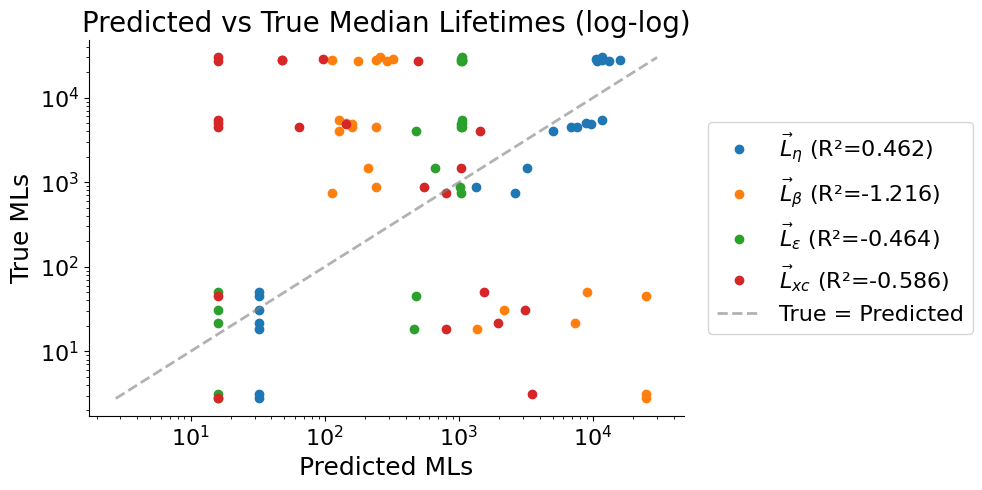

In [23]:
# Plot MLs_eta, MLs_beta, MLs_epsilon, MLs_xc (x-axis) vs True MLs (y-axis), all fonts bigger

# Calculate R2s (if not already calculated in previous cells)
# (Assuming r2_eta, r2_beta, r2_epsilon, r2_xc are available. Otherwise, we recalculate.)
try:
    r2_eta
    r2_beta
    r2_epsilon
    r2_xc
except NameError:
    from sklearn.metrics import r2_score
    r2_eta = r2_score(ml_true, ml_eta)
    r2_beta = r2_score(ml_true, ml_beta)
    r2_epsilon = r2_score(ml_true, ml_epsilon)
    r2_xc = r2_score(ml_true, ml_xc)

plt.figure(figsize=(10,5))
plt.loglog(ml_eta, ml_true, 'o', 
           label=fr'$\vec{{L}}_{{\eta}}$ (R²={r2_eta:.3f})')
plt.loglog(ml_beta, ml_true, 'o', 
           label=fr'$\vec{{L}}_{{\beta}}$ (R²={r2_beta:.3f})')
plt.loglog(ml_epsilon, ml_true, 'o', 
           label=fr'$\vec{{L}}_{{\epsilon}}$ (R²={r2_epsilon:.3f})')
plt.loglog(ml_xc, ml_true, 'o', 
           label=fr'$\vec{{L}}_{{xc}}$ (R²={r2_xc:.3f})')

# Plot true-vs-true dashed gray line with alpha=0.6
all_ml_pred = np.concatenate([ml_eta, ml_beta, ml_epsilon, ml_xc])
lims = [min(all_ml_pred.min(), ml_true.min()), max(all_ml_pred.max(), ml_true.max())]
plt.plot(lims, lims, '--', color='gray', alpha=0.6, label='True = Predicted', linewidth=2)

plt.xlabel("Predicted MLs", fontsize=18)
plt.ylabel("True MLs", fontsize=18)
plt.title("Predicted vs True Median Lifetimes (log-log)", fontsize=20)
plt.legend(fontsize=16, loc='center left', bbox_to_anchor=(1.04, 0.5), borderaxespad=0)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#save fig as pdf
plt.savefig('pred_vs_true_MLs_for_R2_analysis.pdf', bbox_inches='tight')
#save fig as jpg
plt.savefig('pred_vs_true_MLs_for_R2_analysis.jpg', bbox_inches='tight')

plt.tight_layout()
plt.show()


Calculation of correlations (Supplemantary table 8)

In [13]:
#show spearman correlation between MLs and MLs_eta, MLs_beta, MLs_epsilon, MLs_xc
from scipy.stats import spearmanr

print('eta', spearmanr(ml_true, ml_eta))
print('beta', spearmanr(ml_true, ml_beta))
print('epsilon', spearmanr(ml_true, ml_epsilon))
print('xc', spearmanr(ml_true, ml_xc))


eta SignificanceResult(statistic=0.9404541144003664, pvalue=7.900727681436955e-11)
beta SignificanceResult(statistic=-0.544838409083872, pvalue=0.008741057686846875)
epsilon SignificanceResult(statistic=0.8592008619583995, pvalue=3.050741834140181e-07)
xc SignificanceResult(statistic=-0.49662450522556034, pvalue=0.018717959944175806)


In [14]:
# Show Pearson correlation between log-transformed MLs and MLs_eta, MLs_beta, MLs_epsilon, MLs_xc
from scipy.stats import pearsonr

log_ml_true = np.log(ml_true)
log_ml_eta = np.log(ml_eta)
log_ml_beta = np.log(ml_beta)
log_ml_epsilon = np.log(ml_epsilon)
log_ml_xc = np.log(ml_xc)

print('eta', pearsonr(log_ml_true, log_ml_eta))
print('beta', pearsonr(log_ml_true, log_ml_beta))
print('epsilon', pearsonr(log_ml_true, log_ml_epsilon))
print('xc', pearsonr(log_ml_true, log_ml_xc))


eta PearsonRResult(statistic=0.9606809351431297, pvalue=1.3548319446495574e-12)
beta PearsonRResult(statistic=-0.8675529152671418, pvalue=1.7162239637726205e-07)
epsilon PearsonRResult(statistic=0.8325239877366997, pvalue=1.5390400497890712e-06)
xc PearsonRResult(statistic=-0.4506220931217812, pvalue=0.035320143093086814)
